In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)

In [5]:
blockSize = 3


def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * blockSize
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context[:blockSize])
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

In [6]:
import random

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [7]:
g = torch.Generator().manual_seed(349343293)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [8]:
with torch.no_grad():
    emp = C[Xtr]
    h_preact = emp.view(-1, 6) @ W1 + b1
    h = torch.tanh(h_preact)
    logits = h @ W2 + b2
    loss_baseline = F.cross_entropy(logits, Ytr)
    saturation_ratio = (h.abs() > 0.97).float().mean()
    print(f'{loss_baseline.item()=}')
    print(f'{h_preact.mean()}, {h_preact.std()}, {h.mean()}, {h.std()}, {saturation_ratio}')

loss_baseline.item()=25.00247573852539
-0.007843343541026115, 2.614530086517334, -0.004619235172867775, 0.8350399732589722, 0.404676616191864


In [9]:
g = torch.Generator().manual_seed(349343293)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g) * 0.01
b2 = torch.zeros(27)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [10]:
g = torch.Generator().manual_seed(349343293)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g) * (5 / 3) / (6 ** 0.5)
b1 = torch.zeros(300)
W2 = torch.randn((300, 27), generator=g) * 0.01
b2 = torch.zeros(27)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [11]:
with torch.no_grad():
    emp = C[Xtr]
    h_preact = emp.view(-1, 6) @ W1 + b1
    h = torch.tanh(h_preact)
    logits = h @ W2 + b2
    loss_baseline = F.cross_entropy(logits, Ytr)
    saturation_ratio = (h.abs() > 0.97).float().mean()
    print(f'{loss_baseline.item()=}')
    print(f'{h_preact.mean()}, {h_preact.std()}, {h.mean()}, {h.std()}, {saturation_ratio}')

loss_baseline.item()=3.2921297550201416
-0.0009417901746928692, 1.634825587272644, -0.0052872514352202415, 0.7401012778282166, 0.1917659491300583


In [12]:
def activation_stats(C, W1, b1):
    with torch.no_grad():
        emb = C[Xtr]
        hpreact = emb.view(-1, W1.shape[0]) @ W1 + b1
        h = torch.tanh(hpreact)
    return {
        'hpreact_mean': hpreact.mean().item(),
        'hpreact_std': hpreact.std().item(),
        'h_mean': h.mean().item(),
        'h_std': h.std().item(),
        'saturation': (h.abs() > 0.97).float().mean().item(),
    }


# 同一 seed：只改变 W1 的缩放和 b1，因而可以直接比较。
g_compare = torch.Generator().manual_seed(349343293)
C_compare = torch.randn((27, 2), generator=g_compare)
W1_raw = torch.randn((6, 300), generator=g_compare)
b1_raw = torch.randn(300, generator=g_compare)

fan_in = W1_raw.shape[0]
W1_kaiming = W1_raw * (5 / 3) / fan_in ** 0.5
b1_kaiming = torch.zeros(300)

stats = {
    'raw': activation_stats(C_compare, W1_raw, b1_raw),
    'kaiming_tanh': activation_stats(C_compare, W1_kaiming, b1_kaiming),
}

for name, s in stats.items():
    print(f"{name:>12}: hpreact μ={s['hpreact_mean']:+.3f}, σ={s['hpreact_std']:.3f}; "
          f"h μ={s['h_mean']:+.3f}, σ={s['h_std']:.3f}; "
          f"saturated={s['saturation']:.2%}")

         raw: hpreact μ=-0.008, σ=2.615; h μ=-0.005, σ=0.835; saturated=40.47%
kaiming_tanh: hpreact μ=-0.001, σ=1.635; h μ=-0.005, σ=0.740; saturated=19.18%


### S1 结论

每层线性变换的输出方差约与 $fan\_in \cdot \operatorname{Var}(W)$ 成正比。
用 $1/\sqrt{fan\_in}$ 缩放权重，才能防止信号逐层放大；对 tanh 再乘 $5/3$，补偿其压缩方差的效应。

这里 $fan\_in=6$，因为每个隐藏层神经元接收 $block\_size \times n\_embd = 3 \times 2$ 个输入。正确缩放会降低 $hpreact$ 的尺度和 tanh 饱和比例，让梯度更容易流动。

In [13]:
g = torch.Generator().manual_seed(349343293)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g) * (5 / 3) / (6 ** 0.5)
b1 = torch.zeros(300)
W2 = torch.randn((300, 27), generator=g) * 0.01
b2 = torch.zeros(27)

bngain = torch.ones((1, 300))
bnbias = torch.zeros((1, 300))

bnmean_running = torch.zeros((1, 300))
bnvar_running = torch.ones((1, 300))

parameters = [C, W1, W2, b2, bngain, bnbias]

for p in parameters:
    p.requires_grad = True

In [14]:
max_step = 200000
#max_step = 10
batch_size = 32
lossi = []
for i in range(max_step):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(-1, 6)
    hpreact = embcat @ W1

    bnmean = hpreact.mean(0, keepdim=True)
    bnvar = hpreact.var(0, keepdim=True, unbiased=False)

    bnraw = (hpreact - bnmean) / torch.sqrt(bnvar + 1e-5)
    hpreact_bn = bngain * bnraw + bnbias
    h = torch.tanh(hpreact_bn)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)
    lossi.append(loss.item())

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmean
        bnvar_running = 0.999 * bnvar_running + 0.001 * bnvar

    for p in parameters:
        p.grad = None

    loss.backward()
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data = p.data - lr * p.grad

    if i % 1000 == 0:
        print(
            f'{i:7d}/{max_step:7d}: '
            f'loss={loss.item():.4f}, '
            f'running_mean={bnmean_running.mean().item():+.4f}, '
            f'running_var={bnvar_running.mean().item():.4f}'
        )


      0/ 200000: loss=3.3072, running_mean=-0.0000, running_var=1.0009
   1000/ 200000: loss=2.5495, running_mean=+0.0019, running_var=2.0853
   2000/ 200000: loss=2.7658, running_mean=+0.0043, running_var=2.6452
   3000/ 200000: loss=2.6578, running_mean=+0.0066, running_var=2.8438
   4000/ 200000: loss=2.3569, running_mean=+0.0099, running_var=2.8929
   5000/ 200000: loss=2.4215, running_mean=+0.0117, running_var=2.9128
   6000/ 200000: loss=2.5070, running_mean=+0.0128, running_var=2.9335
   7000/ 200000: loss=2.6614, running_mean=+0.0147, running_var=2.9478
   8000/ 200000: loss=2.2729, running_mean=+0.0159, running_var=2.9365
   9000/ 200000: loss=2.6018, running_mean=+0.0167, running_var=2.9722
  10000/ 200000: loss=2.4497, running_mean=+0.0185, running_var=2.9838
  11000/ 200000: loss=2.8896, running_mean=+0.0194, running_var=2.9907
  12000/ 200000: loss=2.0607, running_mean=+0.0201, running_var=2.9787
  13000/ 200000: loss=2.4757, running_mean=+0.0201, running_var=3.0004
  1400

Text(0.5, 0, 'iteration')

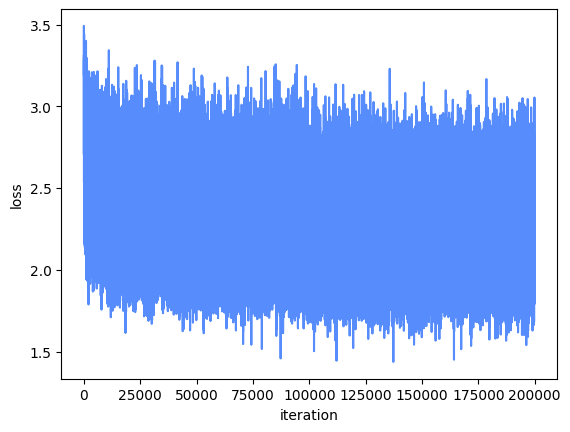

In [15]:
plt.plot(lossi)
plt.ylabel('loss')
plt.xlabel('iteration')

In [16]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev': (Xdev, Ydev),
    }[split]

    emb = C[x]
    embcat = emb.view(-1, 6)
    hpreact = embcat @ W1

    hpreact_bn = (
            bngain
            * (hpreact - bnmean_running)
            / torch.sqrt(bnvar_running + 1e-5)
            + bnbias
    )
    h = torch.tanh(hpreact_bn)
    logits = h @ W2 + b2
    return F.cross_entropy(logits, y)


print('train', split_loss('train').item())
print('dev  ', split_loss('dev').item())

train 2.215111494064331
dev   2.2203667163848877


In [43]:
class Linear:
    def __init__(self, in_features, out_features, bias=True):
        self.in_features = in_features
        self.out_features = out_features
        self.weight = torch.randn(in_features, out_features, generator=g) / in_features ** 0.5
        self.bias = torch.zeros(out_features) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight, ] + ([] if self.bias is None else [self.bias])


class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []


class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = torch.mean(x, dim=0, keepdim=True)
            xvar = torch.var(x, dim=0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1-self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, ] + ([] if self.beta is None else [self.beta])

n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 100  # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)  # for reproducibility

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * blockSize, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size, bias=False),
]

with torch.no_grad():
    layers[-1].weight *= 0.1

    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5 / 3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
    p.requires_grad = True


46970


In [44]:
ix = torch.randint(0, Xtr.shape[0], (32,), generator=g)
x, y = Xtr[ix], Ytr[ix]

emb = C[x]
out = emb.view(-1, n_embd * blockSize)
for layer in layers:
    out = layer(out)

loss = F.cross_entropy(out, y)
print(out.shape, loss.item())  # 预期 (32, 27) 且 loss 为有限数

torch.Size([32, 27]) 3.2868900299072266


In [45]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function

  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  # if i >= 1000:
  #   break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.2920
  10000/ 200000: 2.2244
  20000/ 200000: 1.9072
  30000/ 200000: 2.1398
  40000/ 200000: 2.0606
  50000/ 200000: 2.3132
  60000/ 200000: 2.1782
  70000/ 200000: 2.0551
  80000/ 200000: 2.0086
  90000/ 200000: 2.0156
 100000/ 200000: 2.1920
 110000/ 200000: 2.1556
 120000/ 200000: 2.1688
 130000/ 200000: 1.9284
 140000/ 200000: 2.0333
 150000/ 200000: 2.0352
 160000/ 200000: 2.3926
 170000/ 200000: 2.1376
 180000/ 200000: 2.1671
 190000/ 200000: 2.1053


layer 2: mean=-0.00, std=0.71, saturated=17.16%
layer 5: mean=-0.01, std=0.74, saturated=18.41%
layer 8: mean=-0.01, std=0.77, saturated=19.37%
layer 11: mean=+0.02, std=0.80, saturated=23.25%
layer 14: mean=-0.02, std=0.59, saturated=6.25%


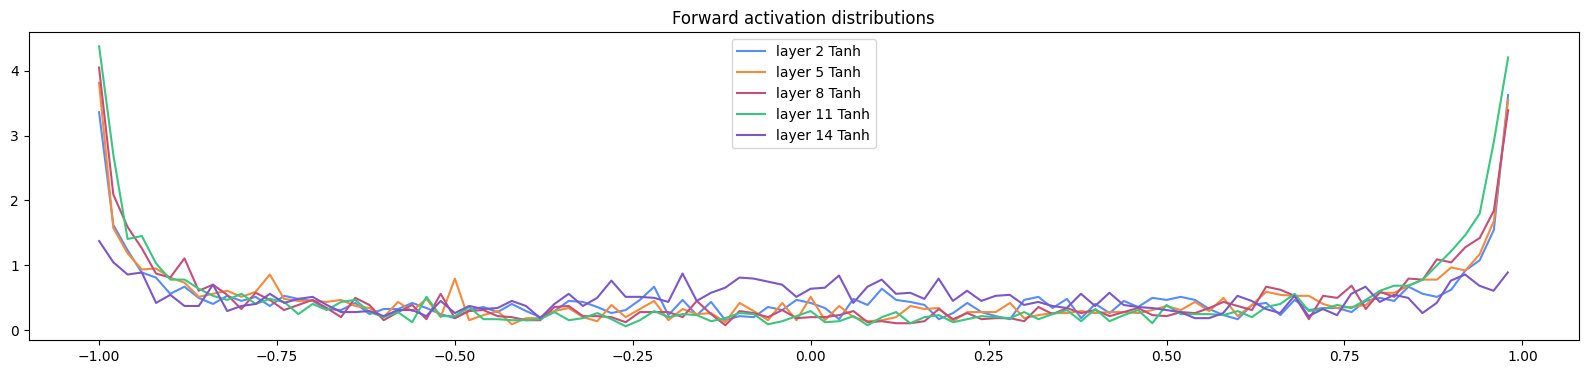

In [46]:
plt.figure(figsize=(20, 4))
legends = []

for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print(
            f'layer {i}: mean={t.mean():+.2f}, std={t.std():.2f}, '
            f'saturated={(t.abs() > 0.97).float().mean():.2%}'
        )
        hy, hx = torch.histogram(t.detach(), density=True)
        plt.plot(hx[:-1], hy)
        legends.append(f'layer {i} Tanh')

plt.legend(legends)
plt.title('Forward activation distributions')
plt.show()

layer 2: grad mean=+2.33e-12, grad std=3.82e-03
layer 5: grad mean=+1.31e-11, grad std=3.62e-03
layer 8: grad mean=+1.25e-11, grad std=3.51e-03
layer 11: grad mean=+1.51e-11, grad std=3.46e-03
layer 14: grad mean=-2.09e-05, grad std=6.52e-03


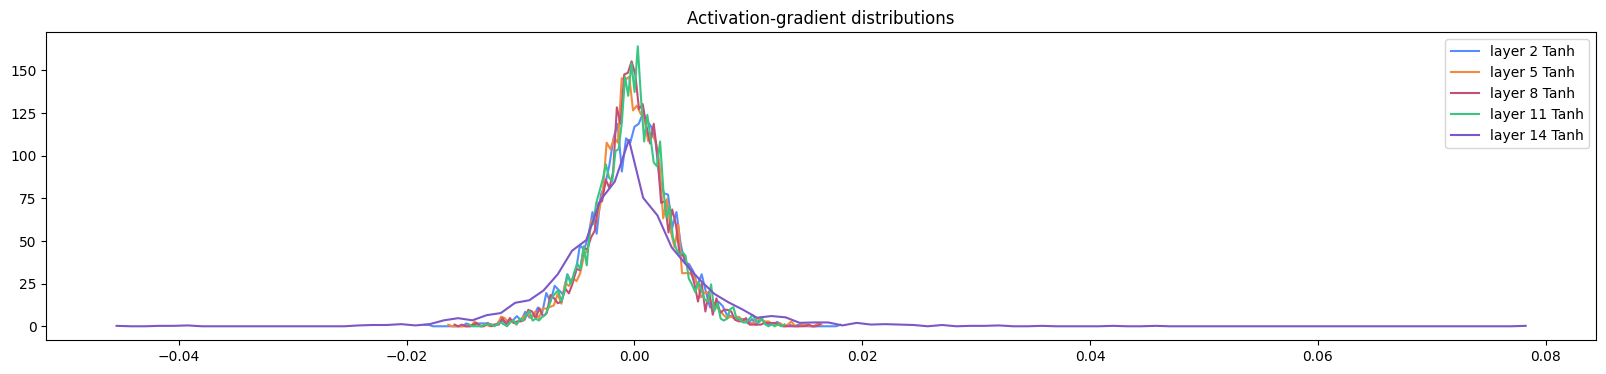

In [47]:
plt.figure(figsize=(20, 4))
legends = []

for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print(f'layer {i}: grad mean={t.mean():+.2e}, grad std={t.std():.2e}')
        hy, hx = torch.histogram(t.detach(), density=True)
        plt.plot(hx[:-1], hy)
        legends.append(f'layer {i} Tanh')

plt.legend(legends)
plt.title('Activation-gradient distributions')
plt.show()

In [48]:
for i, p in enumerate(parameters):
    if p.ndim == 2:  # 只看矩阵权重，不看 bias
        ratio = p.grad.std() / p.data.std()
        print(f'parameter {i}: grad/data = {ratio:.3e}')

parameter 0: grad/data = 1.362e-02
parameter 1: grad/data = 1.637e-02
parameter 4: grad/data = 1.834e-02
parameter 7: grad/data = 1.939e-02
parameter 10: grad/data = 1.922e-02
parameter 13: grad/data = 1.774e-02
parameter 16: grad/data = 6.816e-02


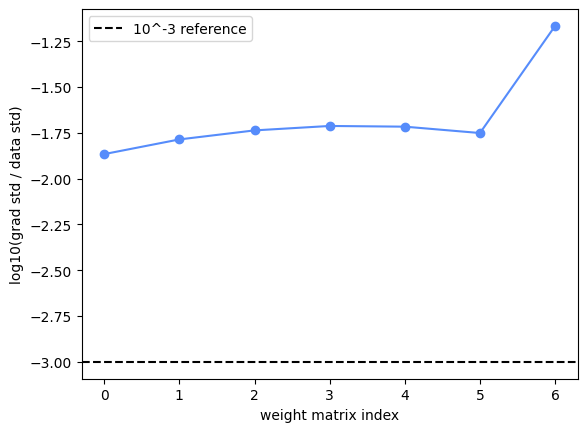

In [49]:
ratios = [
    (p.grad.std() / p.data.std()).log10().item()
    for p in parameters if p.ndim == 2
]

plt.plot(ratios, marker='o')
plt.axhline(-3, color='k', linestyle='--', label='10^-3 reference')
plt.ylabel('log10(grad std / data std)')
plt.xlabel('weight matrix index')
plt.legend()
plt.show()

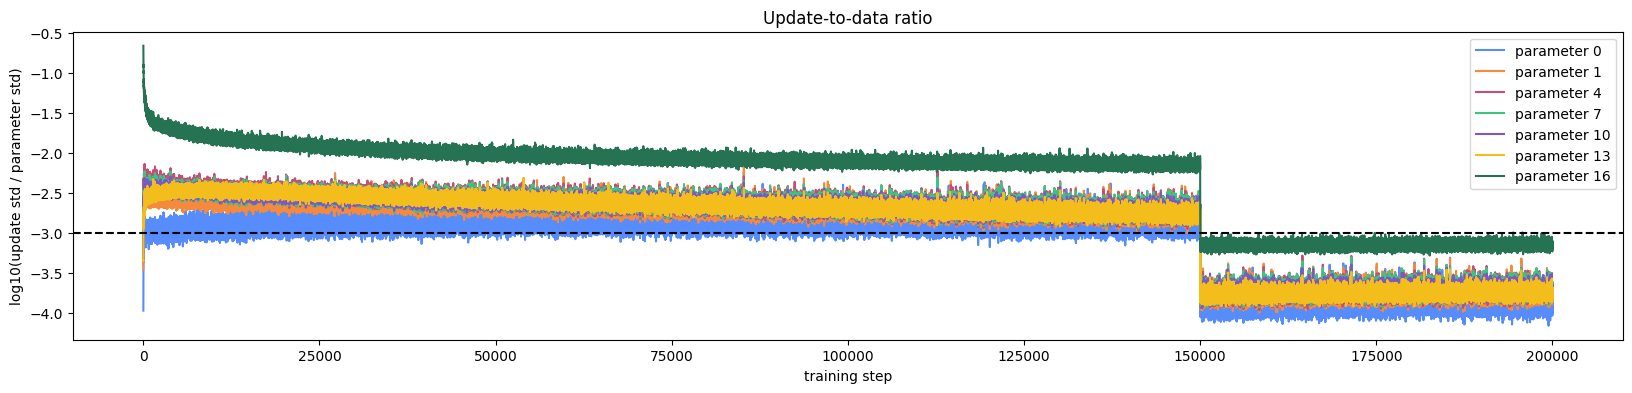

In [50]:
plt.figure(figsize=(20, 4))
legends = []

for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([step[i] for step in ud])
        legends.append(f'parameter {i}')

plt.axhline(-3, color='k', linestyle='--', label='10^-3 reference')
plt.legend(legends)
plt.ylabel('log10(update std / parameter std)')
plt.xlabel('training step')
plt.title('Update-to-data ratio')
plt.show()

In [51]:
for layer in layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

In [52]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    emb = C[x]
    out = emb.view(emb.shape[0], -1)

    for layer in layers:
        out = layer(out)

    return F.cross_entropy(out, y)

print('train:', split_loss('train').item())
print('dev:  ', split_loss('dev').item())
print('test: ', split_loss('test').item())  # P4 唯一一次最终 test

train: 2.0056631565093994
dev:   2.0824501514434814
test:  2.084059000015259


In [53]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    context = [0] * blockSize
    name = []

    while True:
        emb = C[torch.tensor([context])]
        out = emb.view(1, -1)

        for layer in layers:
            out = layer(out)

        probs = F.softmax(out, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        context = context[1:] + [ix]

        if ix == 0:  # '.'
            break

        name.append(itos[ix])

    print(''.join(name))

carmah
amelle
khyimri
ree
caspanden
jazon
nadeliah
jareei
nellara
chaiha
kaleigh
ham
joce
quinthorline
livani
wavero
dearisi
jace
pinsley
dae
